<a href="https://colab.research.google.com/github/ishanpattnaik2020-sketch/calculator/blob/main/Resume_screening__system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,confusion_matrix
import os

In [ ]:
# Load Dataset
file_path = "/content/dataset.csv"

df = pd.read_csv(file_path, engine='python', on_bad_lines='warn')

print("\nDataset Loaded Successfully!")
print("Columns:", df.columns)
print("Total rows:", len(df))
print(df.head())


Dataset Loaded Successfully!
Columns: Index(['ID', 'Name', 'Role', 'Transcript', 'Resume', 'decision',
       'Reason_for_decision', 'Job_Description'],
      dtype='object')
Total rows: 421
          ID             Name                        Role  \
0  jasojo159      Jason Jones       E-commerce Specialist   
1   annma759     Ann Marshall              Game Developer   
2  patrmc729  Patrick Mcclain  Human Resources Specialist   
3  patrgr422    Patricia Gray       E-commerce Specialist   
4  amangr696     Amanda Gross       E-commerce Specialist   

                                          Transcript  \
0  Interviewer: Good morning, Jason. It's great t...   
1  Interview Scene\n\nA conference room with a ta...   
2  Interview Setting: A conference room in a medi...   
3  Here's a simulated professional interview for ...   
4  Here's the simulated interview:\n\nInterviewer...   

                                              Resume decision  \
0  Here's a professional resume for Jas

/tmp/ipython-input-1603124599.py:4: ParserWarning: Skipping line 423: unexpected end of data

  df = pd.read_csv(file_path, engine='python', on_bad_lines='warn')


In [ ]:
# Prepare Data
X_text = df["Resume"]
y = df["Role"]

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(X_text)

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
# Step 6: Train Model
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
# Step 7: Model Accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)


Model Accuracy: 0.8705882352941177


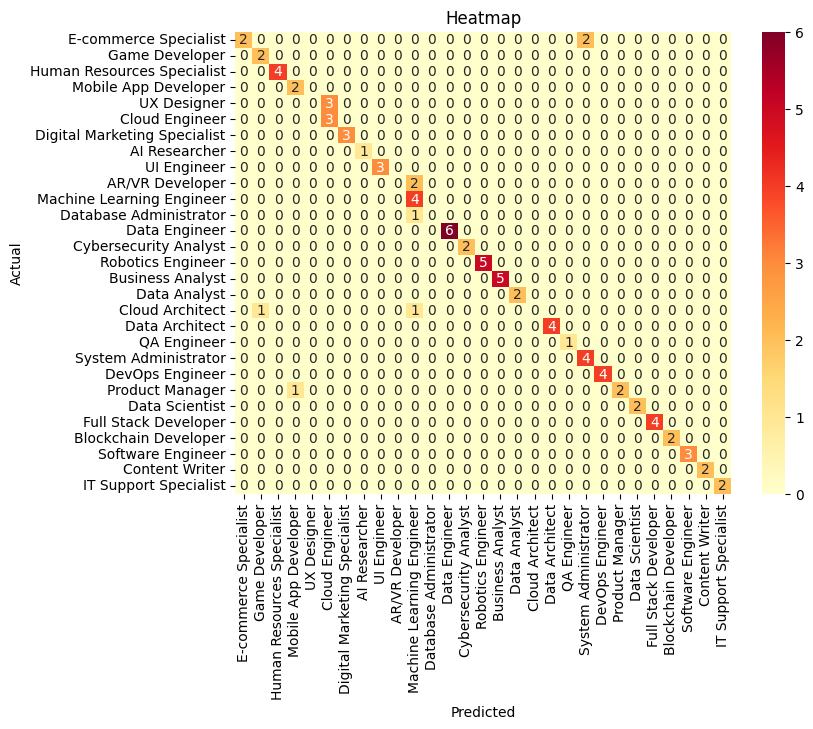

In [ ]:
# Heatmap
cm = confusion_matrix(y_test, y_pred)
labels = y.unique()

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="YlOrRd",
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Heatmap")
plt.show()

In [ ]:
# sample case test
sample_resumes = [
    "Python machine learning deep learning data analysis pandas numpy",
    "Java spring boot microservices REST API backend development",
    "HTML CSS JavaScript React frontend UI design",
    "Accounting finance taxation GST audit Excel",
    "SEO digital marketing social media Google ads content marketing",
    "C++ embedded systems microcontroller electronics circuit design",
    "Data visualization Power BI Tableau SQL analytics",
    "Android development Kotlin Java mobile app development",
    "HR recruitment employee management payroll training",
    "Network security ethical hacking cyber security firewall"
]

print("\n--- Sample Resume Predictions ---\n")

for i, resume in enumerate(sample_resumes, 1):
    vec = vectorizer.transform([resume])
    pred = model.predict(vec)[0]
    print(f"Resume {i}: {pred}")

In [ ]:
# user input
print("\n--- Enter Your Own Resume Text ---")

while True:
    user_text = input("\nEnter resume text (type 'exit' to stop): ")

    if user_text.lower() == "exit":
        print("Prediction stopped.")
        break

    user_vec = vectorizer.transform([user_text])
    user_pred = model.predict(user_vec)[0]

    print("Predicted Job Role:", user_pred)


--- Enter Your Own Resume Text ---
